# AI Mental Health Analyzer EDA

**import**

In [2]:
import pandas as pd
import json 
from collections import Counter
import matplotlib.pyplot as plt

In [3]:

with open("../DepressionEmo/dataset/train.json" ,'r', encoding='utf-8') as f:
    data = [json.loads(line) for line in f]
    
df = pd.DataFrame(data)
print(df.head())

       id                                              title  \
0  hhcq6e                          Found out something awful   
1  d0bobn                I just want to feel wanted ya know?   
2  wy400i                                               Done   
3  crkjga  When nobody else celebrates you, learn to cele...   
4  zq1lwl                                           goodbye.   

                                                post  \
0  My mum had a boyfriend when I was around 6 or ...   
1  Like, I have a ton of friends, I talk to them ...   
2  I’m writing this as I sit on the side of the r...   
3  Feeling unloved can have a huge impact on the ...   
4  I'm done. I have a bottle of jack danials and ...   

                                                text  upvotes  \
0  Found out something awful ### My mum had a boy...       53   
1  I just want to feel wanted ya know? ### Like, ...       51   
2  Done ### I’m writing this as I sit on the side...        8   
3  When nobody els

**Checking Basic Info / Missing Values**

In [4]:
df.describe()
df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4225 entries, 0 to 4224
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        4225 non-null   object
 1   title     4225 non-null   object
 2   post      4225 non-null   object
 3   text      4225 non-null   object
 4   upvotes   4225 non-null   int64 
 5   date      4225 non-null   object
 6   emotions  4225 non-null   object
 7   label_id  4225 non-null   int64 
dtypes: int64(2), object(6)
memory usage: 264.2+ KB


In [5]:
df.head(20)

,id,title,post,text,upvotes,date,emotions,label_id
0,hhcq6e,Found out something awful,My mum had a boyfriend when I was around 6 or ...,Found out something awful ### My mum had a boy...,53,2020-06-28 11:16:59,"[anger, hopelessness, sadness]",10010100
1,d0bobn,I just want to feel wanted ya know?,"Like, I have a ton of friends, I talk to them ...","I just want to feel wanted ya know? ### Like, ...",51,2019-09-06 04:10:27,"[loneliness, sadness, emptiness, hopelessness,...",10111100
2,wy400i,Done,I’m writing this as I sit on the side of the r...,Done ### I’m writing this as I sit on the side...,8,2022-08-26 08:53:35,"[loneliness, hopelessness, sadness, worthlessn...",10111101
3,crkjga,"When nobody else celebrates you, learn to cele...",Feeling unloved can have a huge impact on the ...,"When nobody else celebrates you, learn to cele...",28,2019-08-17 10:28:21,"[loneliness, sadness]",1100
4,zq1lwl,goodbye.,I'm done. I have a bottle of jack danials and ...,goodbye. ### I'm done. I have a bottle of jack...,102,2022-12-19 19:50:52,"[emptiness, hopelessness]",110000
5,nbaxkk,No one wants to admit loneliness,It feels almost shameful to admit we are lonel...,No one wants to admit loneliness ### It feels ...,15,2021-05-13 07:24:12,[loneliness],1000
6,17df22c,The older I get the worse my depression gets,I just miss being happier,The older I get the worse my depression gets #...,5,2023-10-21 23:04:16,"[sadness, hopelessness, brain dysfunction (for...",1010100
7,10z8w72,Share your experience with loneliness,I am interested in hearing others' stories reg...,Share your experience with loneliness ### I am...,5,2023-02-11 01:37:12,[loneliness],1000
8,13bzc5y,I’m going to kill myself,I don’t care anymore it isn’t worth being aliv...,I’m going to kill myself ### I don’t care anym...,301,2023-05-08 17:52:18,"[suicide intent, worthlessness, hopelessness, ...",10111111
9,h7s7yr,I just want to tell my story. I hope it goes t...,When I was 13 years old I got caught stealing ...,I just want to tell my story. I hope it goes t...,61,2020-06-12 20:15:05,"[anger, hopelessness]",10010000


**convert emotions into 8 separate binary columns**

In [6]:
flat_emotions = [emotion for sublist in df['emotions'] for emotion in sublist]
emotion_counts = Counter(flat_emotions)

print(emotion_counts)

Counter({'sadness': 3260, 'hopelessness': 2919, 'worthlessness': 2095, 'loneliness': 1929, 'anger': 1754, 'emptiness': 1573, 'suicide intent': 1035, 'brain dysfunction (forget)': 813})


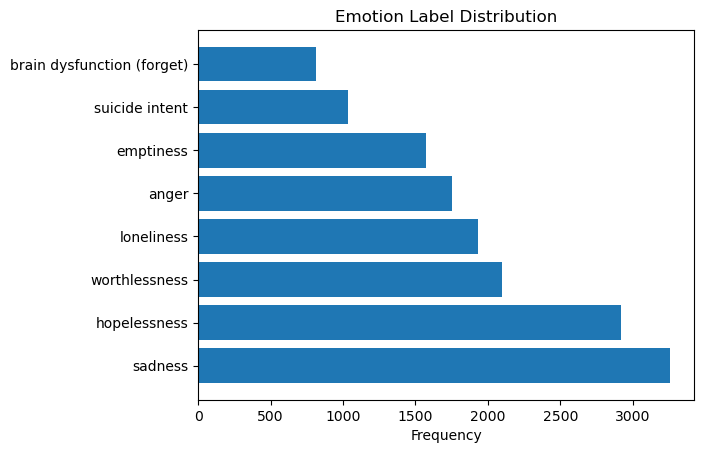

In [7]:
emotion_counts_sorted = dict(sorted(emotion_counts.items(), key=lambda x: x[1], reverse=True))

plt.barh(list(emotion_counts_sorted.keys()), list(emotion_counts_sorted.values()))
plt.xlabel("Frequency")
plt.title("Emotion Label Distribution")
plt.show()

**Checking for mssing values**

In [8]:
df.isnull().sum()

id          0
title       0
post        0
text        0
upvotes     0
date        0
emotions    0
label_id    0
dtype: int64

In [9]:
#checking for post length

df['post_length'] = df['post'].apply(lambda x: len(x.split()))
df['post_length'].describe()

count    4225.000000
mean       91.477396
std        52.843528
min         1.000000
25%        47.000000
50%        89.000000
75%       134.000000
max       219.000000
Name: post_length, dtype: float64

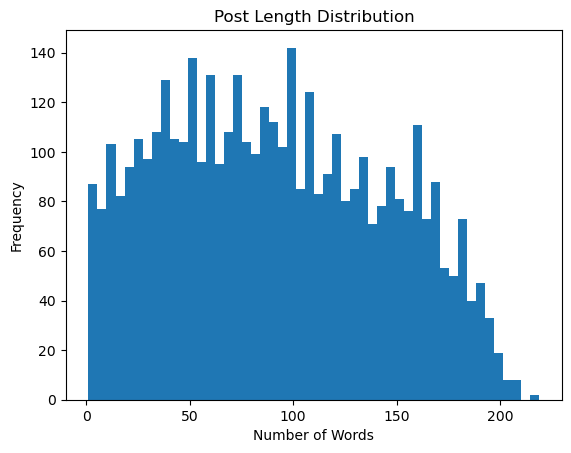

In [10]:
#plot length distribution

plt.hist(df['post_length'], bins=50)
plt.title("Post Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


**Getting average number of emotions per post**

In [12]:
#by defining a new column num_labels 

df['num_labels'] = df['emotions'].apply(len)
df['num_labels'].describe()

count    4225.000000
mean        3.639763
std         1.980834
min         1.000000
25%         2.000000
50%         4.000000
75%         5.000000
max         8.000000
Name: num_labels, dtype: float64

In [14]:
#test